# Comparison of Google Earth Engine Pipelines

The purpose of this file is to compare the outcomes of the hybrid pipeline (here called *hybrid cubes*) against the outcomes of the old Google Earth Engine pipeline (here called *old cubes*).

Prerequisites:

1) Export hybrid cubes with the hybrid inference pipeline by calling 

```
uv run python scripts/developer_scripts/fortress_mountain_basin/build_aoi_cubes_gee_url.py \ 
--aoi data/fortress_mountain_basin_aoi.geojson \ 
--start-date 2025-04-01 \ 
--end-date 2025-04-30 \ 
--tifs-folder fortress_mountain_basin/cubes \ 
--out-csv configs/aoi_cubes/cube_cells.csv
``` 

The random test cubes compared here are 

```PR_20250430_50.8305944570079618_-115.2178997465064043.tif_EPSG:32611.tif```, ```PR_20250401_50.8211690958207285_-115.1898624761783765.tif_EPSG:32611.tif```, ```PR_20250416_50.8303767776966922_-115.2037071683524232.tif_EPSG:32611.tif```, ```PR_20250428_50.8305944570079618_-115.2178997465064043.tif_EPSG:32611.tif```, ```PR_20250414_50.8400131765987524_-115.2459484345066016.tif_EPSG:32611.tif```.

2) Export old cubes from the same dates and locations using the old pipeline, in WGS84, by calling 

```
uv run python -m scripts.export_for_inference --path_to_csv "fortress_test.csv" \  
--tifs_folder "fortress_test" --crs "wgs84"
```
,
where ```fortress_test.csv``` specifies the dates and center coordinate of the filenames of the hybrid cubes. 


3) Reproject the old cubes to the same CRS and transform as the hybrid pipeline (with nearest resampling, as is the default of GEE if I understand correctly, so the resampling mode that should happen implicitly in our pipeline).

In [6]:
import os

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import Resampling, reproject

# folder with the hybrid cubes
hybrid_folder = "test_comparison_hybrid/"

# folder with the old cubes
old_folder = "test_comparison_old/"
old_reprojected_folder = "test_comparison_old_reprojected/"

if not os.path.exists(old_reprojected_folder):
    os.makedirs(old_reprojected_folder)

# First, reproject the old images to match the hybrid images' CRS and transform, then center crop the old images to match the hybrid images' dimensions, and finally compute the difference between the two images.
for i, filename in enumerate(os.listdir(hybrid_folder)):
    fp_path = os.path.join(hybrid_folder, filename)
    old_path = os.path.join(old_folder, os.listdir(old_folder)[i])

    with rasterio.open(fp_path) as fp_src, rasterio.open(old_path) as old_src:
        # Reproject the old image to match the hybrid image's CRS and transform
        old_reprojected_path = os.path.join(old_reprojected_folder, f"{os.listdir(old_folder)[i]}")
        if not os.path.exists(old_reprojected_path):
            with rasterio.open(
                old_reprojected_path,
                "w",
                driver="GTiff",
                height=fp_src.height,
                width=fp_src.width,
                count=old_src.count,
                dtype=old_src.dtypes[0],
                crs=fp_src.crs,
                transform=fp_src.transform,
            ) as old_dst:
                for band in range(1, old_src.count + 1):
                    reproject(
                        source=rasterio.band(old_src, band),
                        destination=rasterio.band(old_dst, band),
                        src_transform=old_src.transform,
                        src_crs=old_src.crs,
                        dst_transform=fp_src.transform,
                        dst_crs=fp_src.crs,
                        resampling=Resampling.nearest,
                    )

4) Center crop the old cubes to the dimensions of the hybrid cubes and compare them visually.

FP: PR_20250401_50.8211690958207285_-115.1898624761783765.tif_EPSG32611.tif has 308 bands
MR: 2025-03-25_2025-04-01_50.8167_-115.197_50.8257_-115.1828_EPSG4326.tif has 308 bands


C:\Users\marle\AppData\Local\Temp\ipykernel_9324\3549363983.py:56: UserWarning: Glyph 61498 (\uf03a) missing from current font.
  plt.tight_layout()


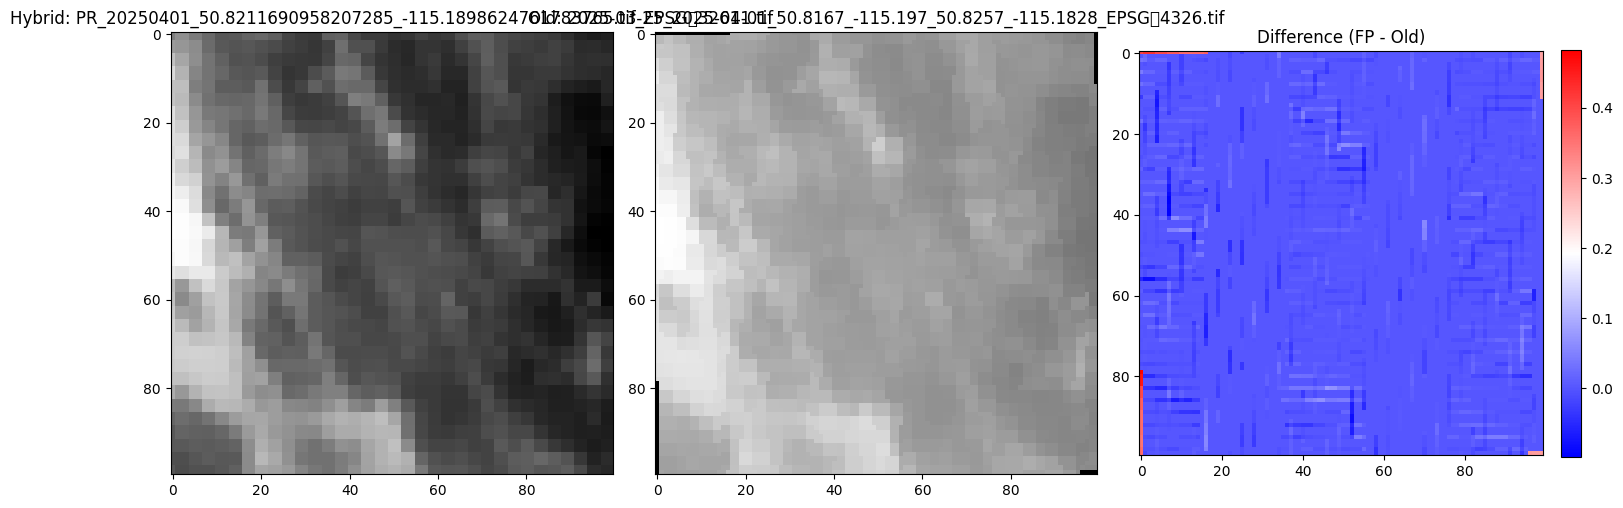

FP: PR_20250414_50.8400131765987524_-115.2459484345066016.tif_EPSG32611.tif has 308 bands
MR: 2025-04-07_2025-04-14_50.8355_-115.253_50.8445_-115.2389_EPSG4326.tif has 308 bands


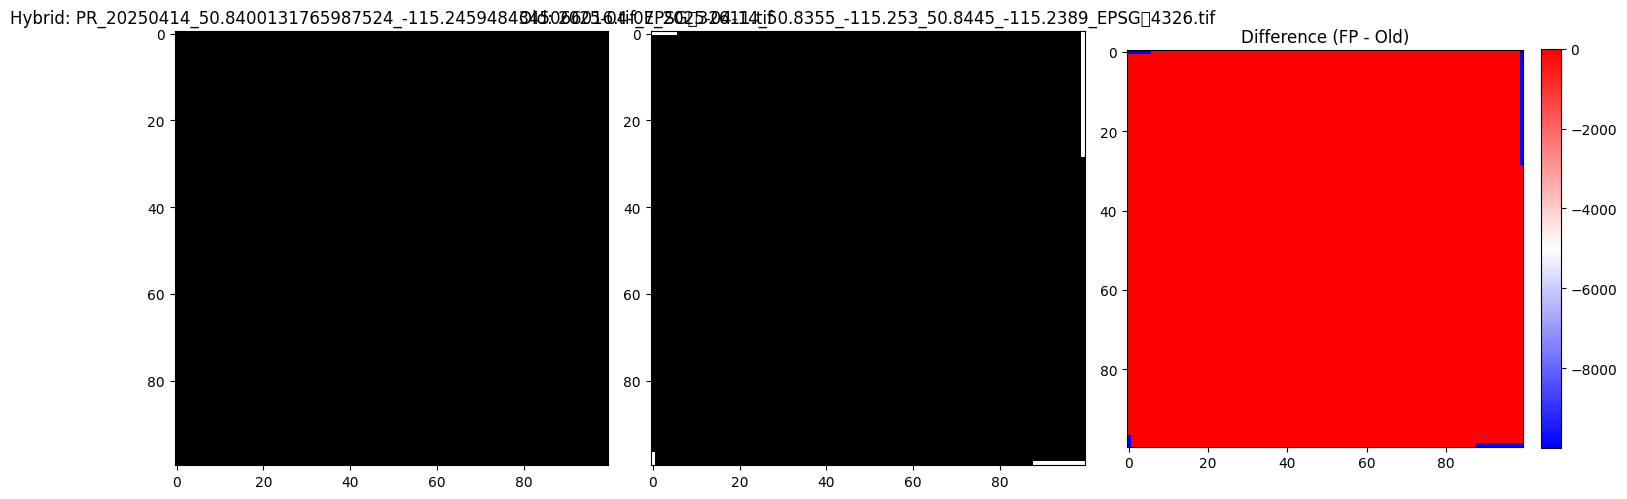

FP: PR_20250416_50.8303767776966922_-115.2037071683524232.tif_EPSG32611.tif has 308 bands
MR: 2025-04-09_2025-04-16_50.8259_-115.2108_50.8349_-115.1966_EPSG4326.tif has 308 bands


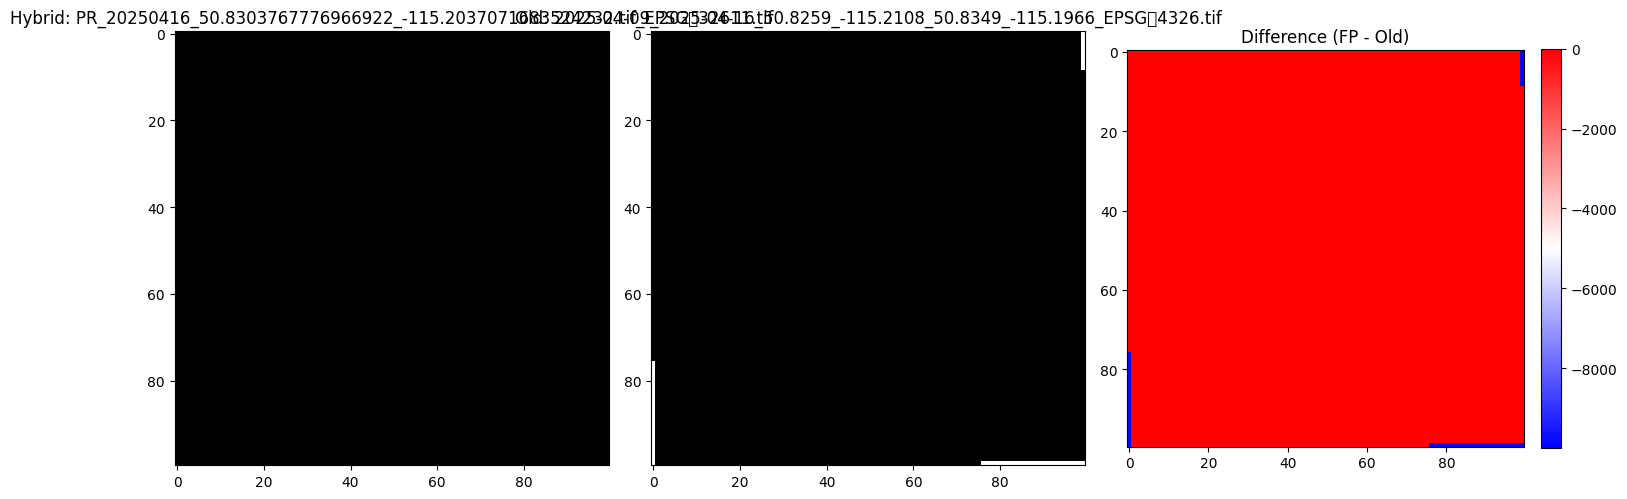

FP: PR_20250428_50.8305944570079618_-115.2178997465064043.tif_EPSG32611.tif has 308 bands
MR: 2025-04-21_2025-04-28_50.8261_-115.225_50.8351_-115.2108_EPSG4326.tif has 308 bands


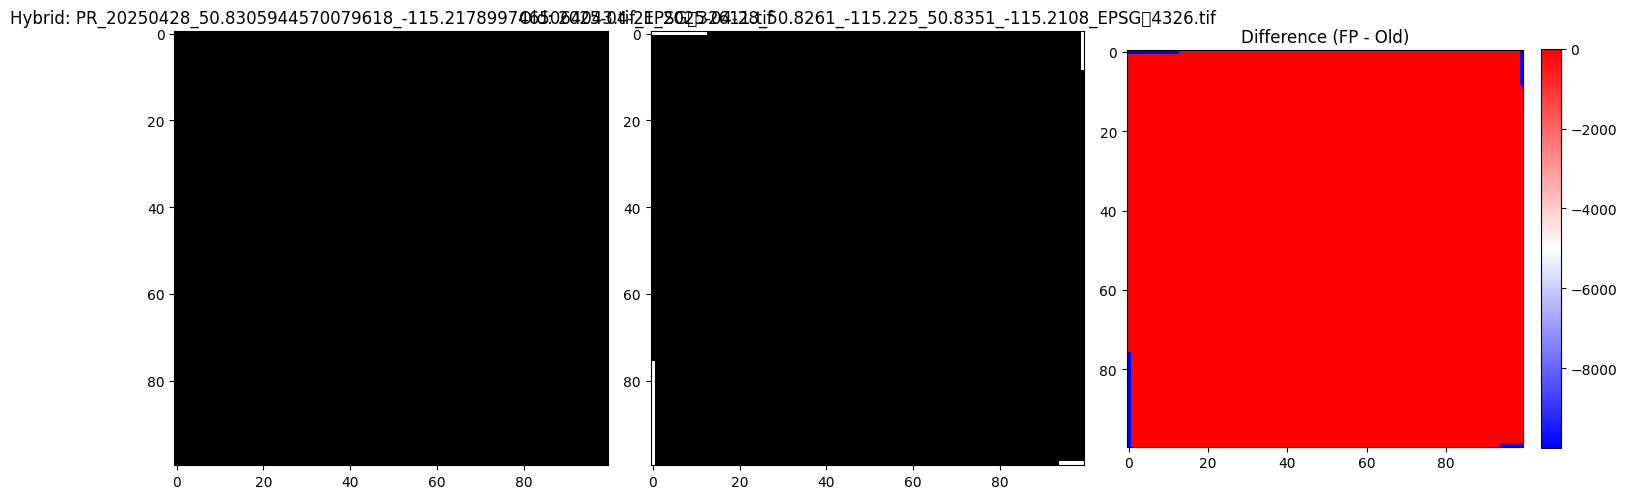

FP: PR_20250430_50.8305944570079618_-115.2178997465064043.tif_EPSG32611.tif has 308 bands
MR: 2025-04-23_2025-04-30_50.8261_-115.225_50.8351_-115.2108_EPSG4326.tif has 308 bands


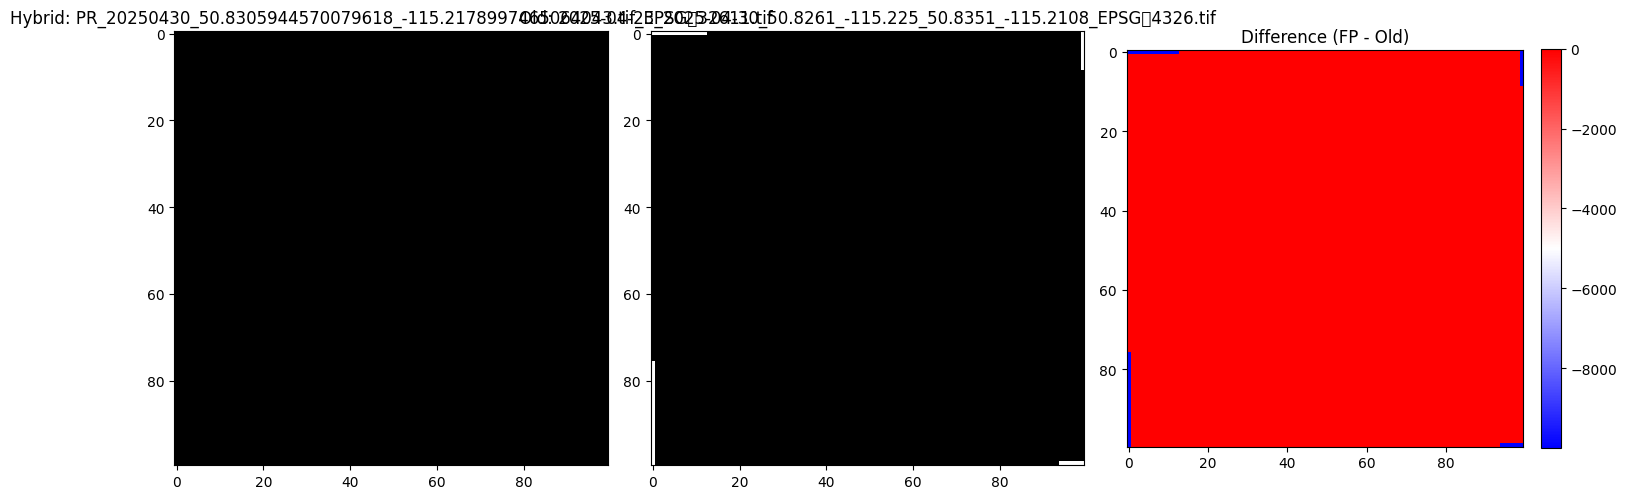

In [8]:
import os

import rasterio

hybrid_folder = "test_comparison_hybrid/"
old_reprojected_folder = "test_comparison_old_reprojected/"

# Change to print a different band number if needed (anything between 1 and 308)
band_number = 10

for i, filename in enumerate(os.listdir(hybrid_folder)):
    fp_path = os.path.join(hybrid_folder, filename)
    old_path = os.path.join(
        old_reprojected_folder, os.listdir(old_reprojected_folder)[i]
    )  # Assuming the files are in the same order

    with rasterio.open(fp_path) as fp_src, rasterio.open(old_path) as old_src:
        # print the number of bands in each image
        print(f"FP: {filename} has {fp_src.count} bands")
        print(f"MR: {os.listdir(old_reprojected_folder)[i]} has {old_src.count} bands")

        # Center crop the old file to the size of the fp file
        fp_width = fp_src.width
        fp_height = fp_src.height
        old_width = old_src.width
        old_height = old_src.height

        # Calculate the crop boundaries for the MR image
        crop_left = (old_width - fp_width) // 2
        crop_right = crop_left + fp_width
        crop_top = (old_height - fp_height) // 2
        crop_bottom = crop_top + fp_height

        # Crop the MR image
        old_data = old_src.read(
            band_number, window=rasterio.windows.Window(crop_left, crop_top, fp_width, fp_height)
        )

        hybrid_data = fp_src.read(band_number)

        # Compute the difference between the two images
        difference = hybrid_data - old_data

        # Plot the images and their difference
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(hybrid_data, cmap="gray", vmin=np.min(hybrid_data), vmax=np.max(hybrid_data))
        axs[0].set_title(f"Hybrid: {filename}")
        axs[1].imshow(old_data, cmap="gray", vmin=np.min(old_data), vmax=np.max(old_data))
        axs[1].set_title(f"Old: {os.listdir(old_reprojected_folder)[i]}")
        axs[2].imshow(difference, cmap="bwr", vmin=np.min(difference), vmax=np.max(difference))
        axs[2].set_title("Difference (FP - Old)")

        # Plot the difference with a colorbar
        im = axs[2].imshow(difference, cmap="bwr")
        plt.colorbar(im, ax=axs[2], orientation="vertical", fraction=0.046, pad=0.04)

        # Show the plots
        plt.tight_layout()
        plt.show()

First insights:

- Generally, both cubes seem to agree when there is no data
- When data is present, the images show generally the same content
- There are some differences at the pixel edges, which might come due to reprojection/resampling differences (see attached image)
- Generally, the hybrid cubes seem to be better since the other ones have edge artefacts (constant values that occur at the edges after reprojection with nearest resampling; in the images below they are displayed as black stripes)